In [ ]:
# -----------------------------------------------------------------------------
# CELL 1: Imports & Setup
# -----------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import requests
import math
import time
from dataclasses import dataclass

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)


Using device: cuda
GPU: Tesla T4


In [ ]:
# -----------------------------------------------------------------------------
# CELL 2: Data -- Tiny Shakespeare
# -----------------------------------------------------------------------------
url = ('https://raw.githubusercontent.com/karpathy/char-rnn/'
       'master/data/tinyshakespeare/input.txt')
text = requests.get(url).text
print(f'Dataset: {len(text):,} characters')

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f'Train: {len(train_data):,} tokens  |  Val: {len(val_data):,} tokens')
print(f'Vocab size: {vocab_size}')

Dataset: 1,115,394 characters
Train: 1,003,854 tokens  |  Val: 111,540 tokens
Vocab size: 65


In [ ]:
# -----------------------------------------------------------------------------
# CELL 3: Hyperparameters
# -----------------------------------------------------------------------------
# Model
BLOCK_SIZE = 256
N_LAYER    = 6
N_HEAD     = 6
N_EMBD     = 384
DROPOUT    = 0.1

# Training
BATCH_SIZE    = 64
MAX_ITERS     = 3000   # ~15 min on T4; raise to 5000 for better convergence
EVAL_INTERVAL = 300
EVAL_ITERS    = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 0.1
GRAD_CLIP     = 1.0
WARMUP_ITERS  = 100

print(f'MAX_ITERS={MAX_ITERS}, BLOCK_SIZE={BLOCK_SIZE}, '
      f'N_EMBD={N_EMBD}, LR={LEARNING_RATE}')

MAX_ITERS=3000, BLOCK_SIZE=256, N_EMBD=384, LR=0.0003


In [ ]:
# -----------------------------------------------------------------------------
# CELL 4: Data Loader
# -----------------------------------------------------------------------------
def get_batch(split):
    source = train_data if split == 'train' else val_data
    ix = torch.randint(len(source) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([source[i:i+BLOCK_SIZE]   for i in ix])
    y = torch.stack([source[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)

In [ ]:
# -----------------------------------------------------------------------------
# CELL 5: Model Architecture
#
# We implement GPT with three attention variants, directly corresponding to
# the paper's G1 gating position (after SDPA, before output projection):
#
#   Baseline:    Y  = Softmax(QK^T / sqrt(d)) * V
#   Gate-Head:   Y' = Y  *  sigmoid(X W_theta)   <- one scalar per head
#   Gate-Elem:   Y' = Y  *  sigmoid(X W_theta)   <- full d_model vector
#
# X is the layer *input* (pre-LayerNorm residual), making the gate
# "query-dependent" as described in the paper.
# -----------------------------------------------------------------------------
@dataclass
class GPTConfig:
    vocab_size: int   = 65
    block_size: int   = 256
    n_layer:    int   = 6
    n_head:     int   = 6
    n_embd:     int   = 384
    dropout:    float = 0.1
    gate_type:  str   = 'none'   # 'none' | 'headwise' | 'elementwise'


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head   = config.n_head
        self.n_embd   = config.n_embd
        self.head_dim = config.n_embd // config.n_head
        self.gate_type = config.gate_type

        # Standard projections
        self.c_attn  = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd,     bias=False)
        self.attn_drop  = nn.Dropout(config.dropout)
        self.resid_drop = nn.Dropout(config.dropout)

        # Causal mask
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(config.block_size, config.block_size))
              .view(1, 1, config.block_size, config.block_size)
        )

        # Gate projection (G1 position)
        if config.gate_type == 'headwise':
            # One scalar per head -> shape (B, T, n_head)
            self.gate_proj = nn.Linear(config.n_embd, config.n_head, bias=True)
        elif config.gate_type == 'elementwise':
            # Full d_model vector -> shape (B, T, n_embd)
            self.gate_proj = nn.Linear(config.n_embd, config.n_embd, bias=True)

        if config.gate_type in ('headwise', 'elementwise'):
            nn.init.zeros_(self.gate_proj.bias)        # sigmoid(0)=0.5 at init
            nn.init.xavier_uniform_(self.gate_proj.weight)

        # Storage for visualization (populated each forward pass)
        self._last_attn   = None
        self._last_gate   = None

    def forward(self, x):
        B, T, C = x.shape

        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        scale = 1.0 / math.sqrt(self.head_dim)
        att = (q @ k.transpose(-2, -1)) * scale          # (B, H, T, T)
        att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        self._last_attn = att.detach()

        y = att @ v                                       # (B, H, T, head_dim)

        # Apply gate at G1 position
        if self.gate_type == 'headwise':
            gate = torch.sigmoid(self.gate_proj(x))      # (B, T, H)
            gate = gate.permute(0, 2, 1).unsqueeze(-1)   # (B, H, T, 1)
            y = y * gate
            self._last_gate = gate.detach()

        elif self.gate_type == 'elementwise':
            gate = torch.sigmoid(self.gate_proj(x))      # (B, T, C)
            gate = gate.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
            y = y * gate
            self._last_gate = gate.detach()

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )
    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config  = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop    = nn.Dropout(config.dropout)
        self.blocks  = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.tok_emb.weight = self.head.weight   # weight tying
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  [{config.gate_type}] {n:,} parameters')

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device)
        x    = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x      = self.ln_f(x)
        logits = self.head(x)
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=40):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat((idx, idx_next), dim=1)
        return idx


print('Architecture defined.')


Architecture defined.


In [ ]:
# -----------------------------------------------------------------------------
# CELL 6: Training Utilities
# -----------------------------------------------------------------------------
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def get_lr(it):
    if it < WARMUP_ITERS:
        return LEARNING_RATE * it / WARMUP_ITERS
    progress = (it - WARMUP_ITERS) / max(1, MAX_ITERS - WARMUP_ITERS)
    return LEARNING_RATE * (0.5 + 0.5 * math.cos(math.pi * progress))


def train_model(gate_type):
    print(f'\n{"="*60}')
    print(f'  Training: gate_type = "{gate_type}"')
    print(f'{"="*60}')

    torch.manual_seed(42)   # same init for fair comparison

    config = GPTConfig(
        vocab_size=vocab_size,
        block_size=BLOCK_SIZE,
        n_layer=N_LAYER,
        n_head=N_HEAD,
        n_embd=N_EMBD,
        dropout=DROPOUT,
        gate_type=gate_type,
    )
    model = GPT(config).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.95),
    )

    history = {'iter': [], 'train_loss': [], 'val_loss': [], 'step_loss': []}
    t0 = time.time()

    for it in range(MAX_ITERS + 1):
        lr = get_lr(it)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        if it % EVAL_INTERVAL == 0:
            losses  = estimate_loss(model)
            elapsed = time.time() - t0
            print(f'  step {it:4d} | train {losses["train"]:.4f} | '
                  f'val {losses["val"]:.4f} | lr {lr:.2e} | {elapsed:.1f}s')
            history['iter'].append(it)
            history['train_loss'].append(losses['train'])
            history['val_loss'].append(losses['val'])
            t0 = time.time()

        if it == MAX_ITERS:
            break

        X, Y = get_batch('train')
        _, loss = model(X, Y)
        history['step_loss'].append(loss.item())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

    print(f'  Done. Final val loss: {history["val_loss"][-1]:.4f}')
    return model, history


In [ ]:
# -----------------------------------------------------------------------------
# CELL 7: Run Training  (~15 min on T4)
# -----------------------------------------------------------------------------
models    = {}
histories = {}

for gate_type in ['none', 'headwise', 'elementwise']:
    m, h = train_model(gate_type)
    models[gate_type]    = m
    histories[gate_type] = h

print('\nAll models trained!')


  Training: gate_type = "none"
  [none] 10,761,600 parameters
  step    0 | train 4.2961 | val 4.2943 | lr 0.00e+00 | 32.8s
  step  300 | train 2.1378 | val 2.1879 | lr 2.96e-04 | 204.9s
  step  600 | train 1.6785 | val 1.8439 | lr 2.79e-04 | 202.7s
  step  900 | train 1.4850 | val 1.6826 | lr 2.47e-04 | 204.3s
  step 1200 | train 1.3725 | val 1.6018 | lr 2.06e-04 | 205.0s
  step 1500 | train 1.3056 | val 1.5504 | lr 1.58e-04 | 205.1s
  step 1800 | train 1.2509 | val 1.5183 | lr 1.10e-04 | 204.9s
  step 2100 | train 1.2143 | val 1.4977 | lr 6.58e-05 | 204.9s
  step 2400 | train 1.1913 | val 1.4880 | lr 3.06e-05 | 205.2s
  step 2700 | train 1.1737 | val 1.4866 | lr 7.85e-06 | 205.4s
  step 3000 | train 1.1724 | val 1.4831 | lr 0.00e+00 | 203.3s
  Done. Final val loss: 1.4831

  Training: gate_type = "headwise"
  [headwise] 10,775,460 parameters
  step    0 | train 4.2681 | val 4.2647 | lr 0.00e+00 | 39.7s
  step  300 | train 2.1306 | val 2.1916 | lr 2.96e-04 | 209.2s
  step  600 | trai

KeyboardInterrupt: 

In [ ]:
# -----------------------------------------------------------------------------
# CELL 8: Plot helpers
# -----------------------------------------------------------------------------
LABELS = {
    'none':        'Baseline (no gate)',
    'headwise':    'Gate-Headwise (G1-head)',
}
COLORS = {
    'none':        '#4C72B0',
    'headwise':    '#DD8452',
}


def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode='valid')


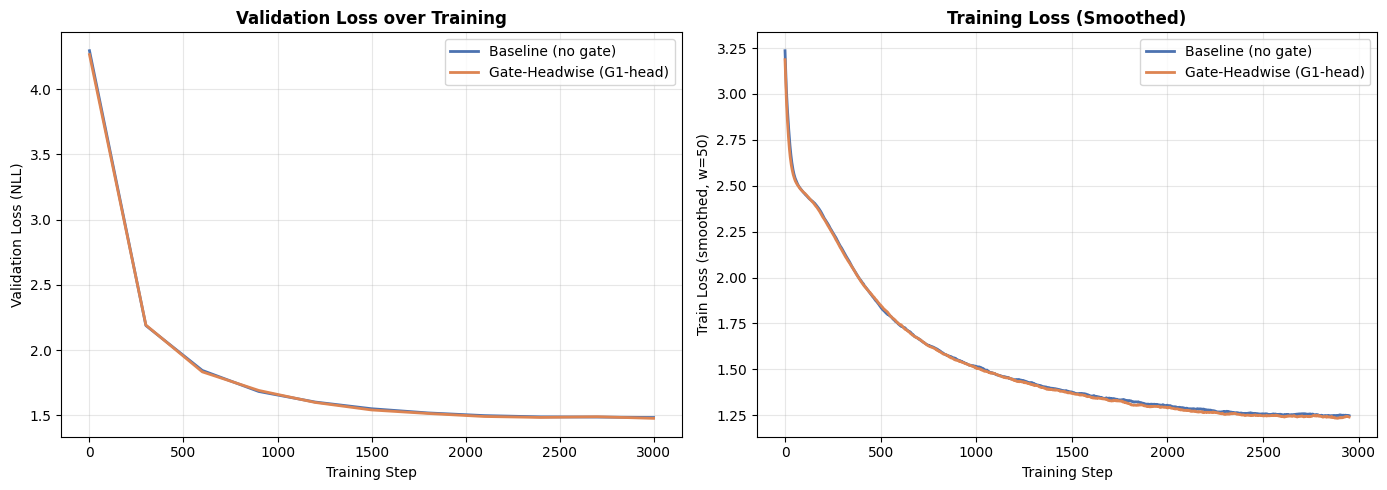

Saved loss_curves.pdf


In [ ]:
# -----------------------------------------------------------------------------
# CELL 9: Figure 1 -- Loss Curves
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for gt in ['none', 'headwise']:
    h = histories[gt]
    ax.plot(h['iter'], h['val_loss'], label=LABELS[gt],
            color=COLORS[gt], linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('Validation Loss (NLL)')
ax.set_title('Validation Loss over Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for gt in ['none', 'headwise']:
    sl = histories[gt]['step_loss']
    ax.plot(smooth(sl), label=LABELS[gt], color=COLORS[gt], linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (smoothed, w=50)')
ax.set_title('Training Loss (Smoothed)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved loss_curves.pdf')


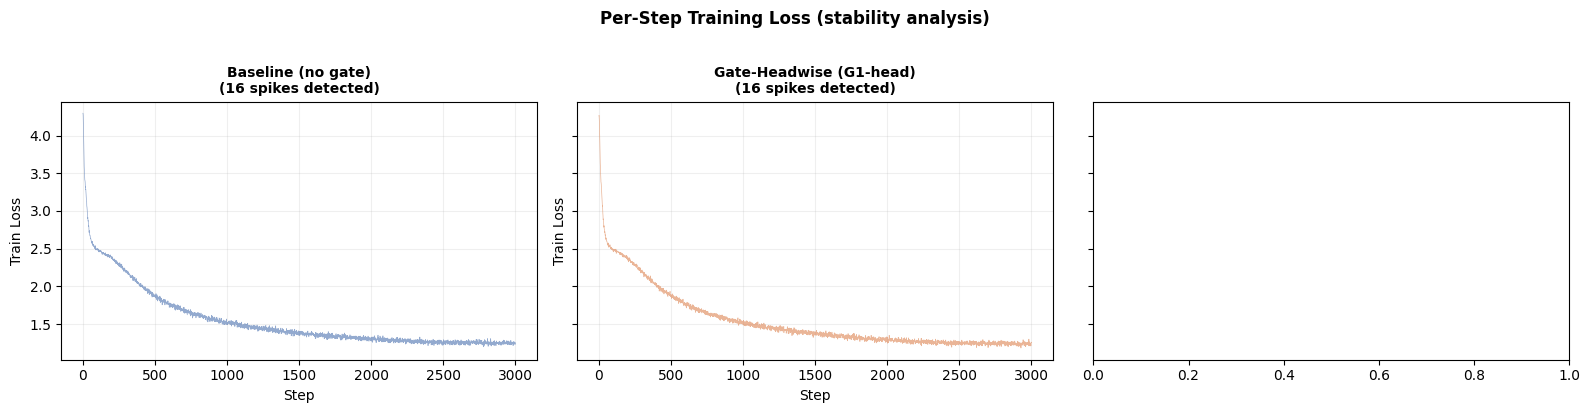

Saved stability_analysis.pdf


In [ ]:
# -----------------------------------------------------------------------------
# CELL 10: Figure 2 -- Training Stability (per-step loss)
# -----------------------------------------------------------------------------
def count_spikes(loss_list, threshold=0.15):
    losses  = np.array(loss_list)
    rolling = np.convolve(losses, np.ones(20) / 20, mode='same')
    return int(np.sum(losses - rolling > threshold))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, gt in zip(axes, ['none', 'headwise']):
    sl = np.array(histories[gt]['step_loss'])
    ax.plot(sl, alpha=0.6, linewidth=0.5, color=COLORS[gt])
    n_spikes = count_spikes(sl)
    ax.set_title(f'{LABELS[gt]}\n({n_spikes} spikes detected)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Step')
    ax.set_ylabel('Train Loss')
    ax.grid(True, alpha=0.2)

plt.suptitle('Per-Step Training Loss (stability analysis)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('stability_analysis.pdf', bbox_inches='tight')
plt.show()
print('Saved stability_analysis.pdf')

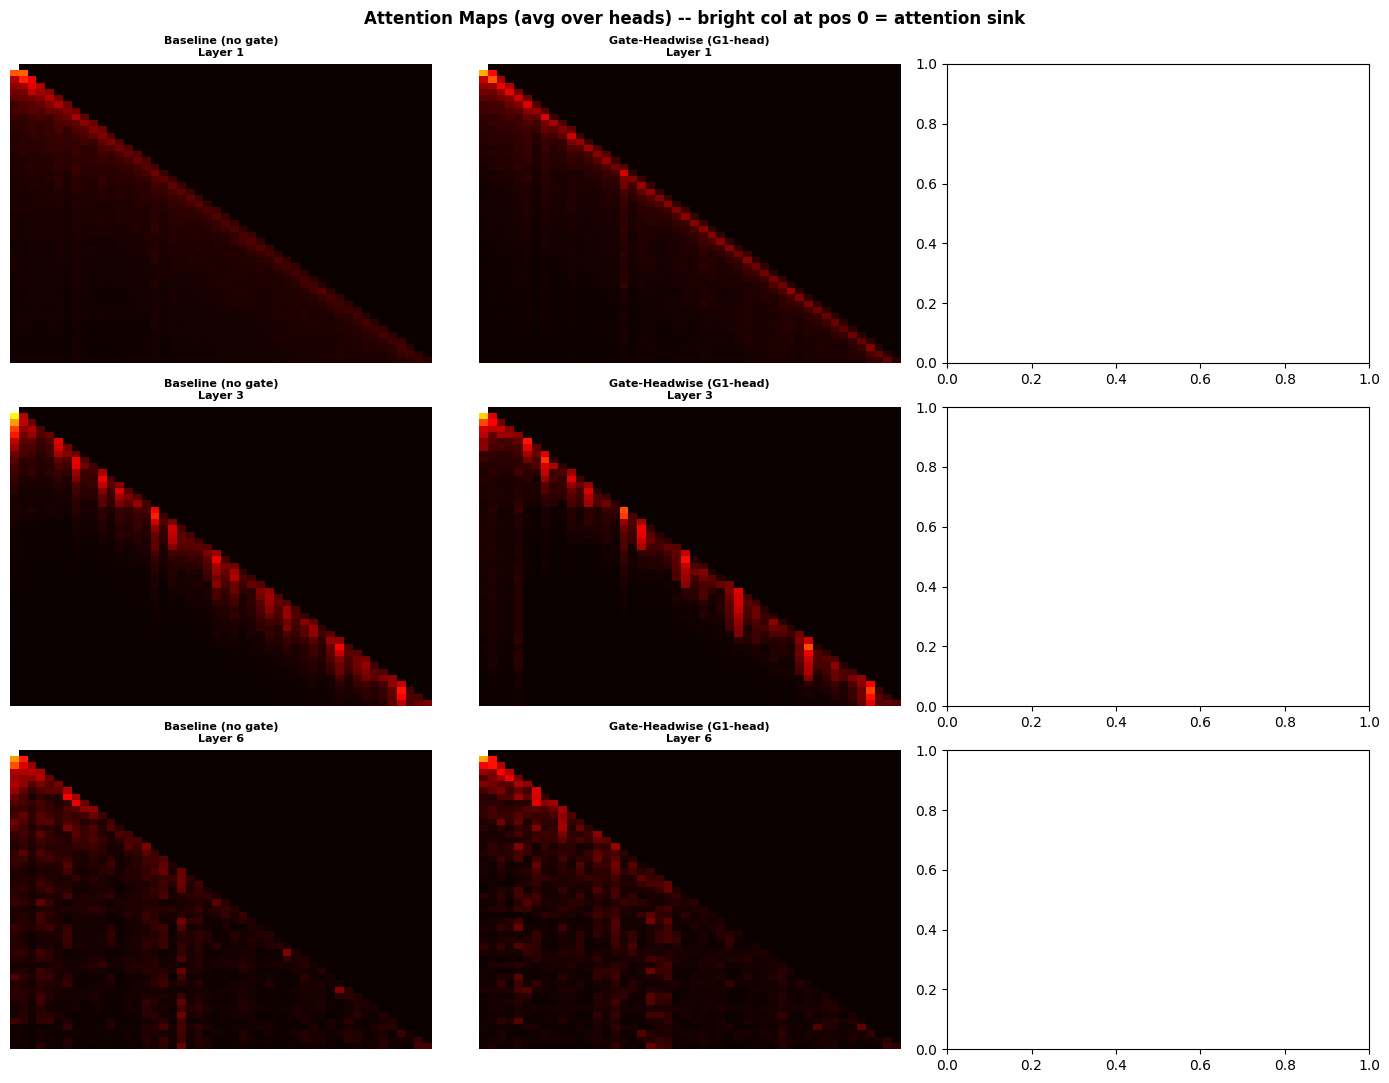

Saved attention_maps.pdf


In [ ]:
# -----------------------------------------------------------------------------
# CELL 11: Figure 3 -- Attention Maps
# -----------------------------------------------------------------------------
PROBE_TEXT = (
    'ROMEO: But, soft! what light through yonder window breaks? '
    'It is the east, and Juliet is the sun. Arise, fair sun,'
)
N_VIZ = 48   # tokens to visualize


@torch.no_grad()
def get_attn_maps(model, txt, n=N_VIZ):
    model.eval()
    idx = torch.tensor([encode(txt)[:n]], dtype=torch.long, device=device)
    model(idx)
    return [block.attn._last_attn[0].cpu().numpy() for block in model.blocks]


fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for col, gt in enumerate(['none', 'headwise']):
    maps = get_attn_maps(models[gt], PROBE_TEXT)
    for row, layer_idx in enumerate([0, 2, 5]):
        ax  = axes[row][col]
        avg = maps[layer_idx].mean(axis=0)   # average over heads
        ax.imshow(avg, aspect='auto', cmap='hot', vmin=0, vmax=avg.max())
        ax.set_title(f'{LABELS[gt]}\nLayer {layer_idx+1}', fontsize=8, fontweight='bold')
        ax.axis('off')

plt.suptitle(
    'Attention Maps (avg over heads) -- bright col at pos 0 = attention sink',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('attention_maps.pdf', bbox_inches='tight')
plt.show()
print('Saved attention_maps.pdf')

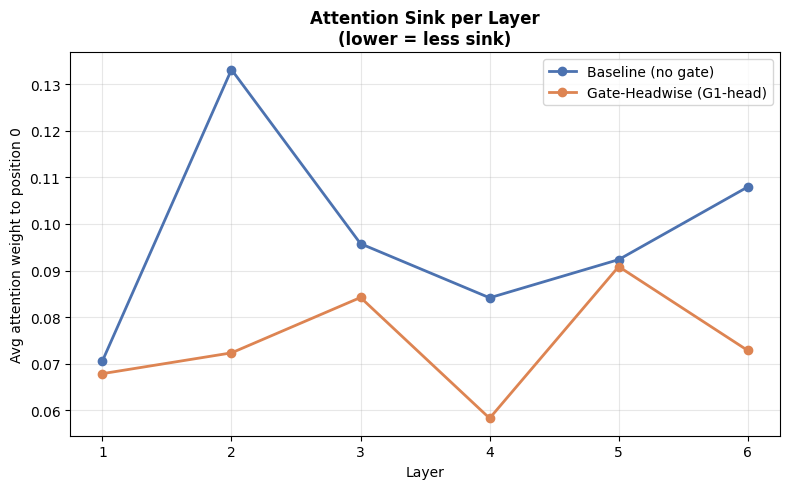

Saved attention_sink.pdf


In [ ]:
# -----------------------------------------------------------------------------
# CELL 12: Figure 4 -- Attention Sink Quantification
# -----------------------------------------------------------------------------
def sink_fraction_per_layer(model, txt, n=N_VIZ):
    maps = get_attn_maps(model, txt, n)
    # mean attention weight to key position 0, across heads and query positions
    return [float(m[:, :, 0].mean()) for m in maps]

fig, ax = plt.subplots(figsize=(8, 5))
layer_ids = list(range(1, N_LAYER + 1))

for gt in ['none', 'headwise']:
    sf = sink_fraction_per_layer(models[gt], PROBE_TEXT)
    ax.plot(layer_ids, sf, marker='o', label=LABELS[gt],
            color=COLORS[gt], linewidth=2)

ax.set_xlabel('Layer')
ax.set_ylabel('Avg attention weight to position 0')
ax.set_title('Attention Sink per Layer\n(lower = less sink)', fontweight='bold')
ax.set_xticks(layer_ids)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attention_sink.pdf', bbox_inches='tight')
plt.show()
print('Saved attention_sink.pdf')

KeyError: 'baseline'

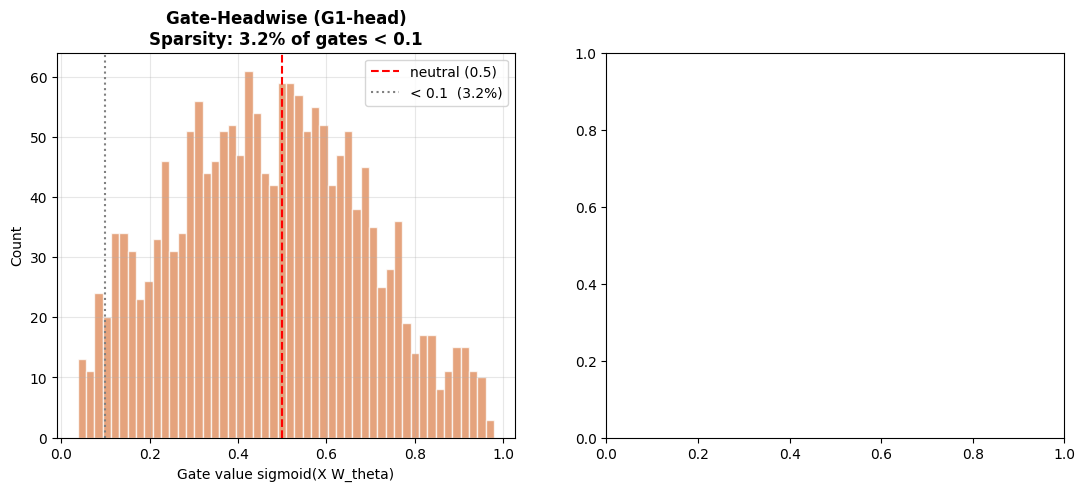

In [ ]:
# -----------------------------------------------------------------------------
# CELL 13: Figure 5 -- Gate Sparsity
# -----------------------------------------------------------------------------
@torch.no_grad()
def get_gate_vals(model, txt, n=N_VIZ):
    model.eval()
    idx = torch.tensor([encode(txt)[:n]], dtype=torch.long, device=device)
    model(idx)
    out = []
    for block in model.blocks:
        gv = block.attn._last_gate
        if gv is not None:
            out.append(gv.cpu().numpy().flatten())
    return out

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, gt in zip(axes, ['headwise', 'baseline']):
    all_gates = np.concatenate(get_gate_vals(models[gt], PROBE_TEXT))
    sparsity  = np.mean(all_gates < 0.1) * 100
    ax.hist(all_gates, bins=50, color=COLORS[gt], alpha=0.75, edgecolor='white')
    ax.axvline(0.5, color='red',  linestyle='--', label='neutral (0.5)')
    ax.axvline(0.1, color='gray', linestyle=':',  label=f'< 0.1  ({sparsity:.1f}%)')
    ax.set_xlabel('Gate value sigmoid(X W_theta)')
    ax.set_ylabel('Count')
    ax.set_title(f'{LABELS[gt]}\nSparsity: {sparsity:.1f}% of gates < 0.1', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gate Value Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('gate_sparsity.pdf', bbox_inches='tight')
plt.show()
print('Saved gate_sparsity.pdf')


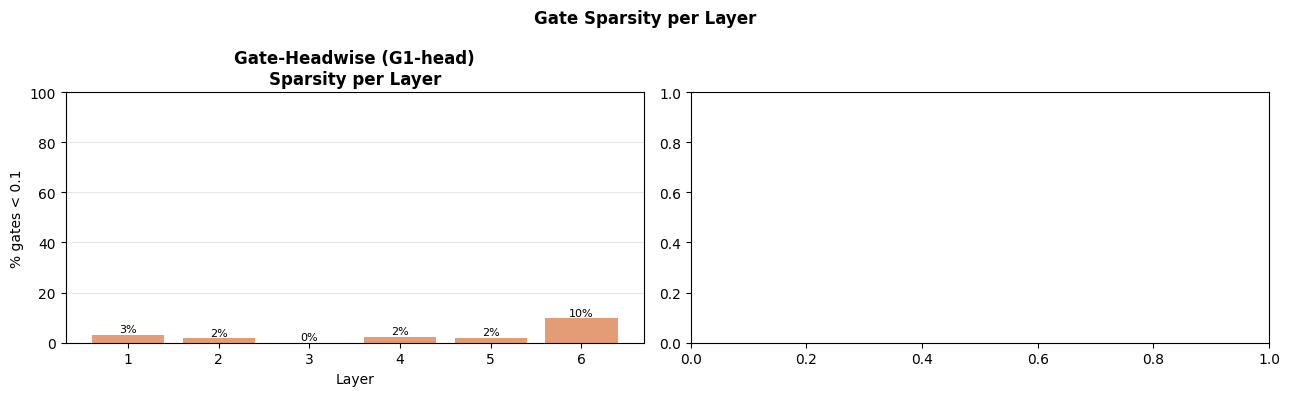

Saved sparsity_per_layer.pdf


In [ ]:
# -----------------------------------------------------------------------------
# CELL 14: Figure 6 -- Per-Layer Sparsity
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, gt in zip(axes, ['headwise']):
    per_layer = [np.mean(gv < 0.1) * 100 for gv in get_gate_vals(models[gt], PROBE_TEXT)]
    bars = ax.bar(range(1, len(per_layer)+1), per_layer, color=COLORS[gt], alpha=0.8)
    ax.set_xlabel('Layer')
    ax.set_ylabel('% gates < 0.1')
    ax.set_title(f'{LABELS[gt]}\nSparsity per Layer', fontweight='bold')
    ax.set_xticks(range(1, len(per_layer)+1))
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, per_layer):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', fontsize=8)

plt.suptitle('Gate Sparsity per Layer', fontweight='bold')
plt.tight_layout()
plt.savefig('sparsity_per_layer.pdf', bbox_inches='tight')
plt.show()
print('Saved sparsity_per_layer.pdf')


In [ ]:
# -----------------------------------------------------------------------------
# CELL 15: Text Generation Samples
# -----------------------------------------------------------------------------
PROMPT = 'ROMEO:\n'

print('=' * 70)
for gt in ['none', 'headwise']:
    m = models[gt]
    m.eval()
    ctx = torch.tensor([encode(PROMPT)], dtype=torch.long, device=device)
    with torch.no_grad():
        out = m.generate(ctx, max_new_tokens=200)
    print(f'\n-- {LABELS[gt]} --')
    print(decode(out[0].tolist()))
    print('=' * 70)


-- Baseline (no gate) --
ROMEO:
I quite of her all the service of my love,
And then it is to cry her proyal your son,
If he did dispatch'd with your hands of me:
Is't the Pompey, what will I would not slay
Like as mercy for commande

-- Gate-Headwise (G1-head) --
ROMEO:
More maid, my soul, when I am with a rests
Are you wretched I think at Rome, and prevail
To counterpring the crown of yours with me;
They shall see his depress'd us.

CAMILLO:
Well, sir, I have a made


In [ ]:
# -----------------------------------------------------------------------------
# CELL 16: Summary Table
# -----------------------------------------------------------------------------
print(f'\n{"Model":<30} {"Train Loss":>12} {"Val Loss":>10} {"Delta Val":>12}')
print('-' * 66)

baseline_val = histories['none']['val_loss'][-1]
for gt in ['none', 'headwise']:
    tl    = histories[gt]['train_loss'][-1]
    vl    = histories[gt]['val_loss'][-1]
    delta = f'{vl - baseline_val:+.4f}' if gt != 'none' else '---'
    print(f'{LABELS[gt]:<30} {tl:>12.4f} {vl:>10.4f} {delta:>12}')

print(f'\nBase val loss: {baseline_val:.4f}')
print('\nFigures saved: loss_curves.pdf, stability_analysis.pdf,')
print('               attention_maps.pdf, attention_sink.pdf,')
print('               gate_sparsity.pdf, sparsity_per_layer.pdf')



Model                            Train Loss   Val Loss    Delta Val
------------------------------------------------------------------
Baseline (no gate)                   1.1724     1.4831          ---
Gate-Headwise (G1-head)              1.1669     1.4767      -0.0064

Base val loss: 1.4831

Figures saved: loss_curves.pdf, stability_analysis.pdf,
               attention_maps.pdf, attention_sink.pdf,
               gate_sparsity.pdf, sparsity_per_layer.pdf


In [ ]:
# -----------------------------------------------------------------------------
# APPENDIX: Parameter overhead
# -----------------------------------------------------------------------------
print(f'\n{"Model":<30} {"Total Params":>15} {"Gate Params":>13} {"Overhead":>10}')
print('-' * 70)
base_n = models['none'].num_params()
for gt in ['none', 'headwise']:
    m     = models[gt]
    total = m.num_params()
    gate_p = sum(
        p.numel()
        for block in m.blocks
        for name, p in block.attn.named_parameters()
        if 'gate' in name
    )
    overhead = f'{(total - base_n) / base_n * 100:.2f}%' if gt != 'none' else '0.00%'
    print(f'{LABELS[gt]:<30} {total:>15,} {gate_p:>13,} {overhead:>10}')


Model                             Total Params   Gate Params   Overhead
----------------------------------------------------------------------
Baseline (no gate)                  10,761,600             0      0.00%
Gate-Headwise (G1-head)             10,775,460        13,860      0.13%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')